# 02 · Modeling, imbalance, calibration and cost-based threshold
Flow: split → baseline → LightGBM → imbalance comparison → Optuna tuning → calibration → cost threshold → test.
The 20% test set is touched **once**, at the end. Everything before uses CV on the 80% training set.

In [6]:
import sys, glob, warnings
sys.path.insert(0, "..")            # make `src` importable from notebooks/
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50, "display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

from src import features as ft, evaluate as ev, train as tr, fairness as fr

DATA = sorted(glob.glob("../data/*.xls*") + glob.glob("../data/*.csv"))[0]   # see data/README.md
print("Using", DATA)

Using ../data\default_of_credit_card_clients.xls


In [7]:
N_TRIALS = 50          # Optuna trials. 15 is fine for a quick pass
C_FN, C_FP = 5.0, 1.0  # a missed defaulter costs 5x a false alarm (assumption, see section 6)

df = ft.add_group_labels(ft.clean(ft.load_raw(DATA)))
tr_idx, te_idx = ft.make_split(df)
X, y = ft.get_xy(df, engineered=True)
X_raw, _ = ft.get_xy(df, engineered=False)
X_tr, X_te, y_tr, y_te = X.iloc[tr_idx], X.iloc[te_idx], y.iloc[tr_idx], y.iloc[te_idx]
print(X_tr.shape, X_te.shape, f"default rate train {y_tr.mean():.3f} / test {y_te.mean():.3f}")

(23972, 47) (5993, 47) default rate train 0.221 / test 0.221


## 1-2. Baseline first, then the main model
Logistic regression (with scaling) is the bar to beat. Showing raw vs engineered features separates the value of **feature engineering** from the value of **a stronger model**.

In [8]:
base = tr.cv_compare({
    "LogReg (raw features)":         (tr.make_logreg(), X_raw.iloc[tr_idx]),
    "LogReg (engineered)":           (tr.make_logreg(), X_tr),
    "LightGBM default (engineered)": (tr.make_lgbm(), X_tr),
}, X_tr, y_tr)
base.round(4)

,roc_auc,roc_auc_sd,pr_auc,pr_auc_sd,brier,brier_sd
model,,,,,,
LogReg (raw features),0.7232,0.0090,0.5028,0.0131,0.1451,0.0016
LogReg (engineered),0.7629,0.0082,0.5134,0.0141,0.1401,0.0022
LightGBM default (engineered),0.7849,0.0086,0.5592,0.0130,0.1341,0.0023


## 3. Imbalance handling: plain vs class weights vs SMOTE


In [9]:
imb = tr.cv_compare(tr.imbalance_strategies(), X_tr, y_tr)
display(imb.round(4))
chosen = tr.choose_strategy(imb)
print("Chosen strategy:", chosen, "(plain is preferred unless another wins PR-AUC by > 0.002)")

,roc_auc,roc_auc_sd,pr_auc,pr_auc_sd,brier,brier_sd
model,,,,,,
plain,0.7849,0.0086,0.5592,0.0130,0.1341,0.0023
class_weight,0.7844,0.0098,0.5596,0.0127,0.1684,0.0036
smote,0.7743,0.0078,0.5364,0.0095,0.1430,0.0023


Chosen strategy: plain (plain is preferred unless another wins PR-AUC by > 0.002)


## 4. Tuning with Optuna (stratified 5-fold CV, objective = PR-AUC)

In [10]:
def build_chosen(**p):
    if chosen == "class_weight": return tr.make_lgbm(class_weight="balanced", **p)
    if chosen == "smote":        return tr.imbalance_strategies(p)["smote"]
    return tr.make_lgbm(**p)

best_params, study = tr.tune_lgbm(X_tr, y_tr, build=build_chosen, n_trials=N_TRIALS)
print(f"Best CV PR-AUC: {study.best_value:.4f}"); best_params

Best CV PR-AUC: 0.5659


{'n_estimators': 400,
 'learning_rate': 0.015368159090700058,
 'num_leaves': 19,
 'min_child_samples': 21,
 'subsample': 0.7689309435395966,
 'colsample_bytree': 0.9418203432282044,
 'reg_lambda': 2.429271766101442,
 'reg_alpha': 0.10580890749885229}

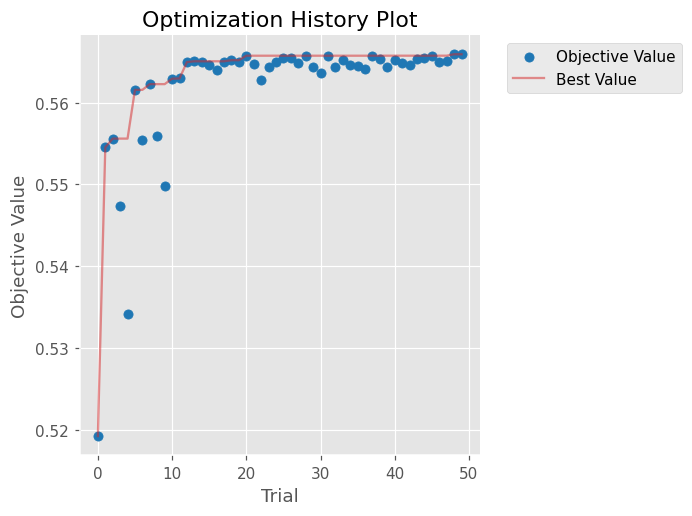

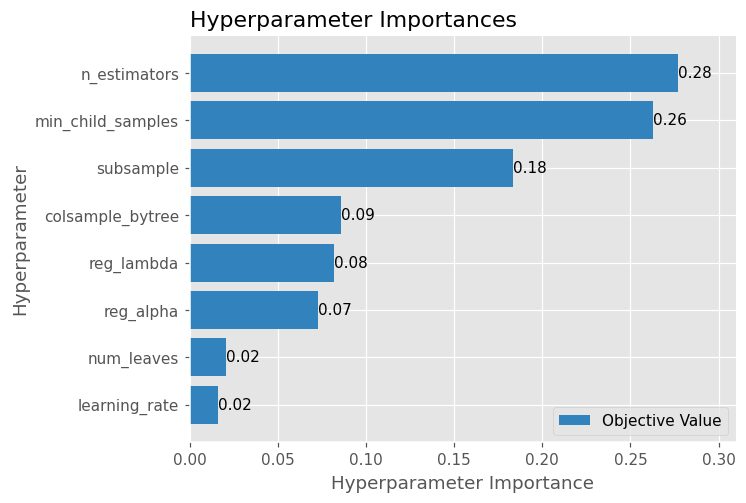

In [11]:
import optuna.visualization.matplotlib as ovm
ovm.plot_optimization_history(study); plt.savefig("../reports/figures/optuna_history.png", bbox_inches="tight")
ovm.plot_param_importances(study);    plt.savefig("../reports/figures/optuna_param_importance.png", bbox_inches="tight")

## 5. Calibration
A lender uses the probability itself (expected loss, limit decisions), so it must be trustworthy. Calibrators are fit on **out-of-fold** predictions and compared with cross-fitting.

,roc_auc,pr_auc,brier,log_loss,ece,base_rate
model,,,,,,
none,0.7895,0.5639,0.1328,0.4233,0.0050,0.2213
platt,0.7894,0.5632,0.1329,0.4234,0.0044,0.2213
isotonic,0.7871,0.5552,0.1331,0.4253,0.0049,0.2213


Best by Brier: none


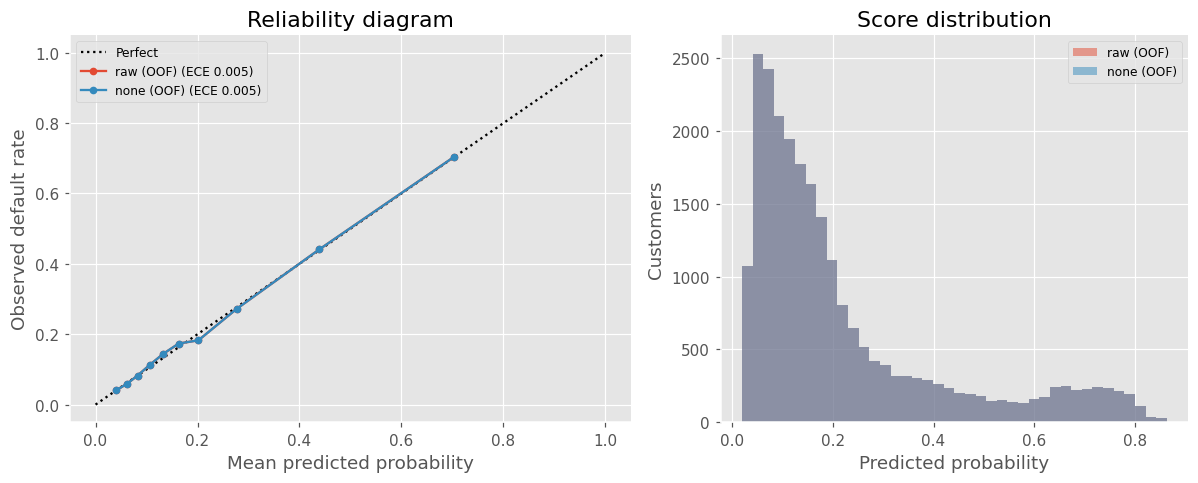

In [12]:
model = build_chosen(**best_params)
p_oof = tr.oof_proba(model, X_tr, y_tr)
cal_table, best_cal = tr.compare_calibrators(p_oof, y_tr)
display(cal_table.round(4)); print("Best by Brier:", best_cal)
p_oof_cal = tr.cv_calibrate(p_oof, y_tr, best_cal)
ev.plot_calibration(y_tr, {"raw (OOF)": p_oof, f"{best_cal} (OOF)": p_oof_cal}, save="calibration_oof.png");

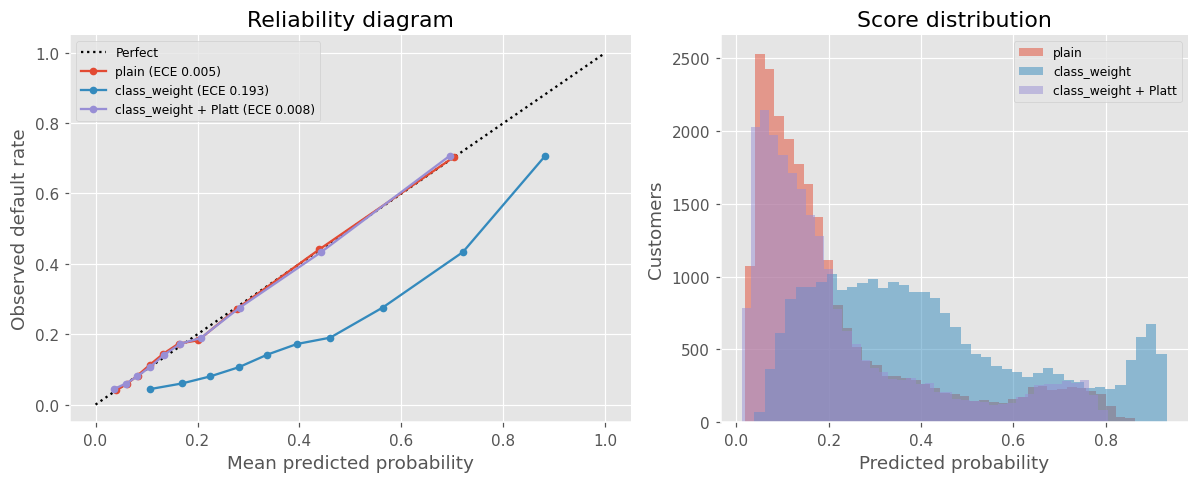

In [13]:
p_cw = tr.oof_proba(tr.make_lgbm(class_weight="balanced", **best_params), X_tr, y_tr)
ev.plot_calibration(
    y_tr,
    {"plain": p_oof, "class_weight": p_cw, "class_weight + Platt": tr.cv_calibrate(p_cw, y_tr, "platt")},
    save="calibration_class_weight.png",
);

## 6. Cost-based threshold
We assume a missed defaulter (no early outreach) costs **5×** a false alarm (needless limit cut or call). For calibrated probabilities the optimal rule is `flag if p > c_fp / (c_fp + c_fn)` = 1/6 ≈ 0.17. We check that the empirical optimum agrees. The threshold is chosen on **out-of-fold** scores.

Empirical optimum 0.150 vs theory 0.167


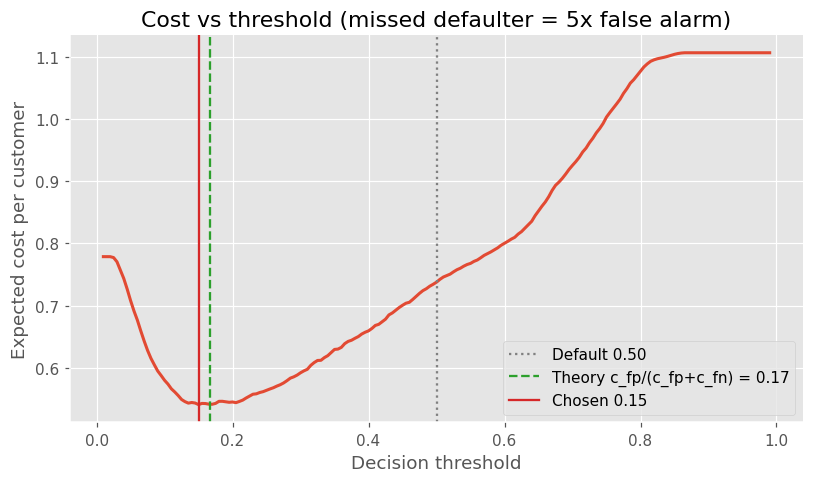

In [14]:
thr = ev.pick_threshold(y_tr, p_oof_cal, C_FN, C_FP)
print(f"Empirical optimum {thr:.3f} vs theory {ev.theoretical_threshold(C_FN, C_FP):.3f}")
ev.plot_cost_curve(y_tr, p_oof_cal, C_FN, C_FP, chosen=thr, save="cost_vs_threshold.png");

## 7. One-time test-set evaluation

,roc_auc,pr_auc,brier,log_loss,ece,base_rate
model,,,,,,
LogReg baseline,0.7540,0.5210,0.1406,0.4461,0.0131,0.2213
LightGBM raw,0.7817,0.5691,0.1343,0.4278,0.0112,0.2213
LightGBM none-calibrated,0.7817,0.5691,0.1343,0.4278,0.0112,0.2213


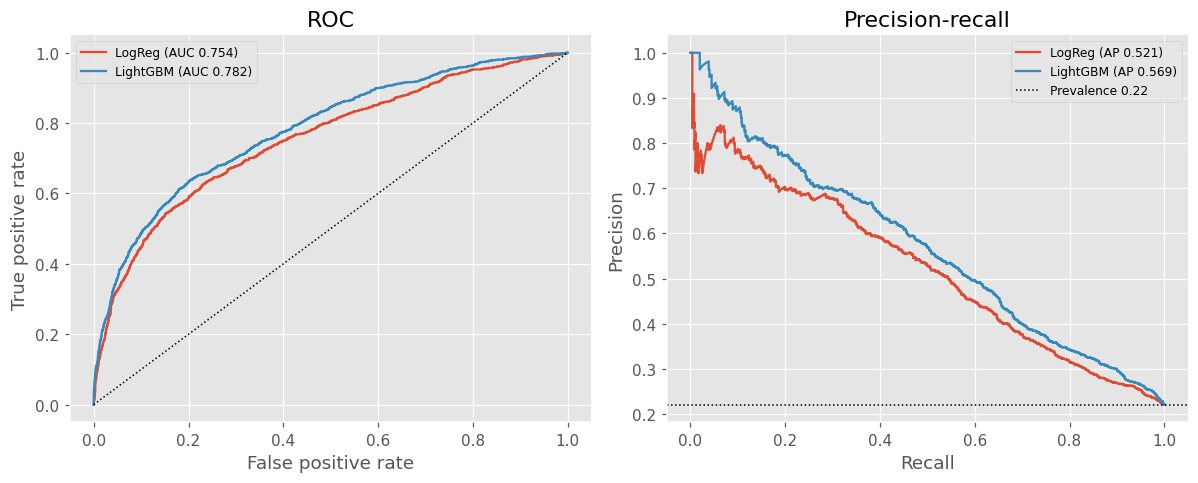

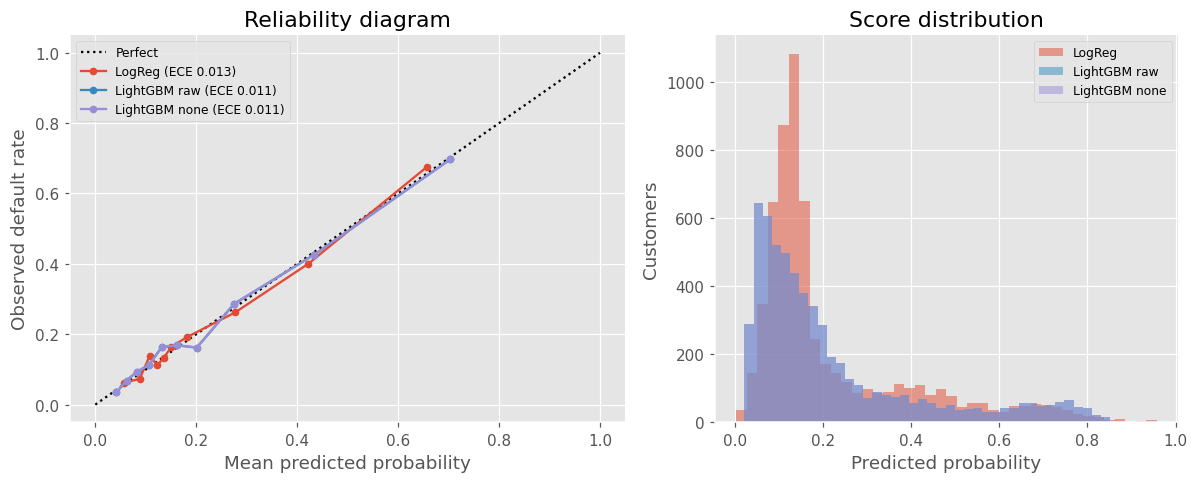

In [15]:
calibrator = tr.CALIBRATORS[best_cal]().fit(p_oof, y_tr)
model.fit(X_tr, y_tr)
p_raw = model.predict_proba(X_te)[:, 1]; p_cal = calibrator.predict(p_raw)
p_lr = tr.make_logreg().fit(X_tr, y_tr).predict_proba(X_te)[:, 1]

scores = pd.DataFrame([ev.score_summary(y_te, p_lr, "LogReg baseline"),
                       ev.score_summary(y_te, p_raw, "LightGBM raw"),
                       ev.score_summary(y_te, p_cal, f"LightGBM {best_cal}-calibrated")]).set_index("model")
display(scores.round(4))
ev.plot_roc_pr(y_te, {"LogReg": p_lr, "LightGBM": p_cal}, save="roc_pr_test.png");
ev.plot_calibration(y_te, {"LogReg": p_lr, "LightGBM raw": p_raw, f"LightGBM {best_cal}": p_cal}, save="calibration_test.png");

In [16]:
display(ev.baseline_costs(y_te, p_cal, thr, C_FN, C_FP).round(4))
print("\nSensitivity to the cost assumption (threshold picked on OOF, evaluated on test):")
display(ev.cost_ratio_sensitivity(y_tr, p_oof_cal, p_cal, y_te).round(3))

,policy,cost_per_customer,flag_rate,recall,precision
0,Flag nobody,1.1063,0.0000,0.0000,0.0000
1,Flag everybody,0.7787,1.0000,1.0000,0.2213
2,Model @ 0.50,0.7452,0.1195,0.3620,0.6704
3,Model @ 0.15 (cost-optimal),0.5625,0.4854,0.7753,0.3534



Sensitivity to the cost assumption (threshold picked on OOF, evaluated on test):


,cost_ratio,threshold,theory,flag_rate,recall,test_cost_per_customer
0,2,0.310,0.333,0.221,0.538,0.307
1,3,0.260,0.250,0.260,0.588,0.403
2,5,0.150,0.167,0.485,0.775,0.562
3,10,0.090,0.091,0.715,0.916,0.699
4,20,0.045,0.048,0.939,0.989,0.767


## 8. Persist artifacts for notebook 03
(`python -m src.train --data ...` produces the same artifacts headlessly.)

In [17]:
import joblib
out = tr.ROOT / "artifacts"; out.mkdir(exist_ok=True)
pred = df.iloc[te_idx].copy(); pred["row_id"] = te_idx
pred["p_logreg"], pred["p_raw"], pred["p_cal"] = p_lr, p_raw, p_cal
pred.to_csv(out / "test_predictions.csv", index=False)
pd.DataFrame({"y": y_tr.values, "p_oof": p_oof, "p_oof_cal": p_oof_cal}).to_csv(out / "oof_predictions.csv", index=False)
joblib.dump({"model": model, "calibrator": calibrator, "threshold": thr, "features": list(X.columns),
             "strategy": chosen, "calibration": best_cal, "params": best_params,
             "test_idx": te_idx, "train_idx": tr_idx, "c_fn": C_FN, "c_fp": C_FP}, out / "model.joblib")
scores.round(4).to_csv(tr.ROOT / "reports" / "test_scores.csv")